# Run Parcels — raw zarr + cache (PR #2668), 1M particles

Advect 1,000,000 surface particles using the raw-zarr loader from parcels PR
[#2668](https://github.com/parcels-code/Parcels/pull/2668): the CMEMS store is
read via `parcels.open_raw_zarr` behind a zarr `CacheStore` (in-memory chunk
cache), bypassing dask. This mirrors the `zarr-with-cache` mode of the
`raw_zarr_testing/raw_zarr_profiling.py` experiment. Kernel:
`Pixi: cmems_global (pr2668-open-raw-zarr)`.

`open_raw_zarr` reads the store raw (no CF-decoding), so it relies on
`01_retrieve_data` having written the fields as NaN-filled `float32` (packed
int16 would come through unscaled). The variables stay backed by bare
`zarr.Array`s and are read lazily — chunk-by-chunk through the `CacheStore`
during interpolation. We deliberately do NOT slice depth here: any xarray
indexing (e.g. `.isel`) on a raw `zarr.Array` triggers an eager full read,
which would defeat the cache; depth handling is left to the cached store.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import parcels
import zarr
from zarr.experimental.cache_store import CacheStore

/tmp/ipykernel_1697068/140998424.py:5: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
data_dir = "/work/bk1450/b381575/elphe-hackathon_data"

In [3]:
print(parcels.__version__)

3.1.3.dev2112


In [4]:
store = CacheStore(
    store=zarr.storage.LocalStore(Path(data_dir) / "cmems_uovo_2001.zarr"),
    cache_store=zarr.storage.MemoryStore(),
    max_size=2**33,
)
ds_fields = parcels.open_raw_zarr(store)
ds_fields

<xarray.Dataset> Size: 35GB
Dimensions:    (time: 10, depth: 50, latitude: 2041, longitude: 4320)
Coordinates:
  * time       (time) datetime64[ns] 80B 2001-01-01 2001-01-02 ... 2001-01-10
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 8kB -80.0 -79.92 -79.83 ... 89.83 89.92 90.0
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
Data variables:
    uo         (time, depth, latitude, longitude) float32 18GB <Array wrappin...
    vo         (time, depth, latitude, longitude) float32 18GB <Array wrappin...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

In [5]:
fields = {"U": ds_fields["uo"], "V": ds_fields["vo"]}
ds_fset = parcels.convert.copernicusmarine_to_sgrid(fields=fields)
fieldset = parcels.FieldSet.from_sgrid_conventions(ds_fset)
print(fieldset)

<FieldSet>
    fields:
        <Field 'U'>
            Parcels attributes:
                name            : 'U'
                interp_method   : <parcels.interpolators._xinterpolators.XLinear object at 0x1553bbf17a10>
                time_interval   : TimeInterval(left=np.datetime64('2001-01-01T00:00:00.000000000'), right=np.datetime64('2001-01-10T00:00:00.000000000'))
                igrid           : -1
            DataArray:
                <xarray.DataArray 'U' (time: 10, depth: 50, lat: 2041, lon: 4320)> Size: 18GB
                <Array wrapping-file:///work/bk1450/b381575/elphe-hackathon_data/cmems_uovo_2...
                Coordinates:
                  * time     (time) datetime64[ns] 80B 2001-01-01 2001-01-02 ... 2001-01-10
                  * depth    (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
                  * lat      (lat) float32 8kB -80.0 -79.92 -79.83 -79.75 ... 89.83 89.92 90.0
                  * lon      (lon) float32 17kB -180.0 -179.9 -179.

In [6]:
n_particles = 1_000_000

lon = np.random.uniform(-80, 20, size=(n_particles,))
lat = np.random.uniform(-35, 40, size=(n_particles,))
z = np.full_like(lon, ds_fields.depth.values[0])  # surface
time = np.array(
    [ds_fields.time.values[0] for _ in range(n_particles)]
)  # initial time of the input data

pset = parcels.ParticleSet(
    fieldset=fieldset,
    pclass=parcels.Particle,
    time=time,
    z=z,
    lat=lat,
    lon=lon,
)
print(pset)

<ParticleSet>
    Number of particles: 1000000
    Particles:
        P[0]: time=0.000000, z=0.494025, lat=30.737196, lon=-48.214890, particle_id=0.000000
        P[1]: time=0.000000, z=0.494025, lat=11.974294, lon=-12.564475, particle_id=1.000000
        P[2]: time=0.000000, z=0.494025, lat=36.867558, lon=-48.495174, particle_id=2.000000
        P[3]: time=0.000000, z=0.494025, lat=18.740906, lon=-5.849612, particle_id=3.000000
        P[4]: time=0.000000, z=0.494025, lat=22.617071, lon=14.222311, particle_id=4.000000
        P[5]: time=0.000000, z=0.494025, lat=18.649626, lon=14.003424, particle_id=5.000000
        P[6]: time=0.000000, z=0.494025, lat=8.733680, lon=-72.526299, particle_id=6.000000
        ...
        P[999999]: time=0.000000, z=0.494025, lat=30.878073, lon=-25.877306, particle_id=999999.000000
    Pclass:
        Variable(name='time', dtype=dtype('float64'), initial=0, to_write=True, attrs={'standard_name': 'time', 'units': 'seconds', 'axis': 'T'})
        Variable(n

In [7]:
kernels = [parcels.kernels.AdvectionRK4]

In [8]:
output_file = parcels.ParticleFile(
    "02c_trajectories.parquet", outputdt=np.timedelta64(6, "h"), mode="w"
)

In [9]:
pset.execute(
    kernels,
    runtime=np.timedelta64(9, "D"),
    dt=np.timedelta64(2, "h"),
    output_file=output_file,
)

INFO: Output files are stored in 02c_trajectories.parquet
Integration time: 2001-01-09T18:00:00 100%|██████████| [16:14<00:00, 798.14it/s]


In [10]:
df = parcels.read_particlefile("02c_trajectories.parquet")
df

time,z,lat,lon,particle_id
datetime[ns],f32,f32,f32,i64
2001-01-01 00:00:00,0.494025,30.737196,-48.21489,0
2001-01-01 00:00:00,0.494025,11.974294,-12.564475,1
2001-01-01 00:00:00,0.494025,36.867558,-48.495174,2
2001-01-01 00:00:00,0.494025,18.740906,-5.849612,3
2001-01-01 00:00:00,0.494025,22.617071,14.222311,4
…,…,…,…,…
2001-01-10 00:00:00,0.494025,39.404766,-23.305569,999995
2001-01-10 00:00:00,0.494025,-3.485478,4.086224,999996
2001-01-10 00:00:00,0.494025,13.40245,-74.86586,999997


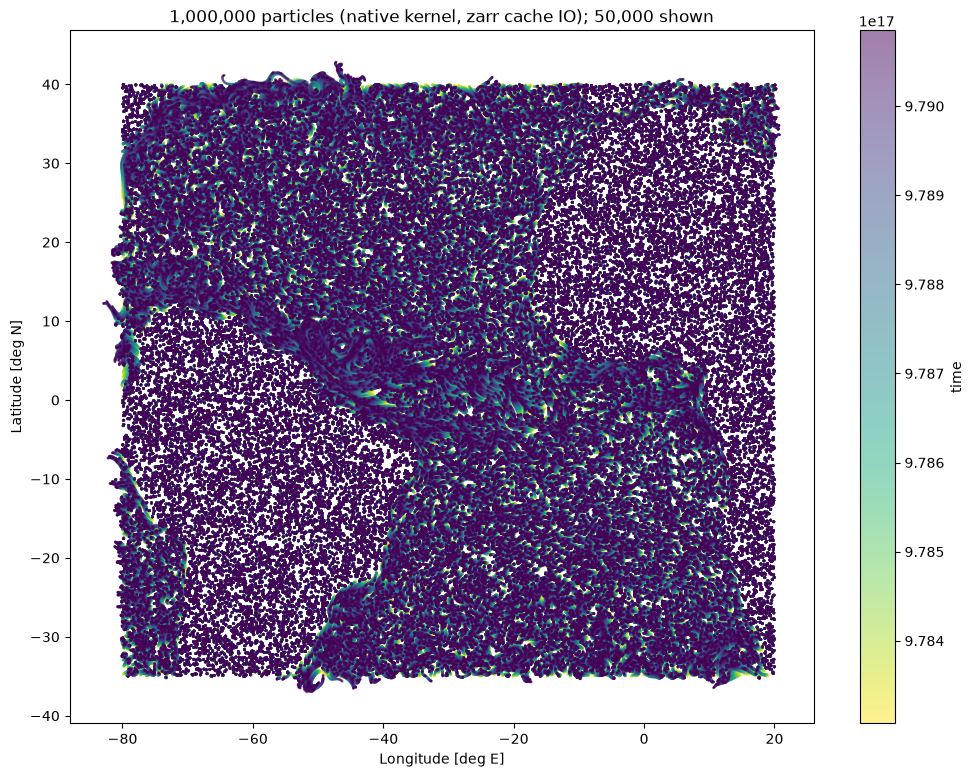

In [11]:
n_plot = min(50_000, n_particles)
rng = np.random.default_rng(0)
plot_ids = rng.choice(n_particles, size=n_plot, replace=False)
pdf = df.to_pandas()
_df = pdf[np.isin(pdf["particle_id"].to_numpy(), plot_ids)]

fig, ax = plt.subplots(figsize=(12, 9))
scatter = ax.scatter(
    _df["lon"], _df["lat"], c=_df["time"], s=1, alpha=0.5, cmap="viridis_r"
)
ax.set_xlabel("Longitude [deg E]")
ax.set_ylabel("Latitude [deg N]")
ax.set_title(f"{n_particles:,} particles (native kernel, zarr cache IO); {n_plot:,} shown")
fig.colorbar(scatter, ax=ax, label="time")
plt.show()